# Week 7 Lecture Jupyter Notebook

## **We will use both Jupyter Notebook and VS Code in this lecture.** Please have them ready.

## Put the following two function definitions, permute1 and permute2, into a file named  ``permute.py``, using **VS Code**.

In [ ]:
from time import time
from permute import permute1, permute2

seq = "1234567890"

start = time()
permute1(seq)
end = time()
print(f"Function-based elapsed time: {end - start:.5f} seconds")

start = time()
permute2(seq)
end = time()
print(f"Generator-based elapsed time: {end - start:.5f} seconds")

# Modules: The Big Picture

In concrete terms, modules typically correspond to Python program files. Each file is a module, and modules import other modules to use the names they define. However, Module files generally don’t do anything when run directly. Rather, **they define tools intended for use in other programs.**

**import**:
Let a client (importer) fetch a module as a whole

**from...import**:
Allows clients to fetch particular names from a module

**importlib.reload**:
Provides a way to reload a module’s code without stopping Python

### Python Program Architecture

In practice, programs usually involve more than just one file. Python fosters a modular program structure that groups functionality into coherent and reusable units. Below figure sketches the structure of a Python program composed of three files: a.py, b.py, and c.py. The file a.py is chosen to be the top-level file; it will be a simple text file of statements, which is executed from top to bottom when launched. The files b.py and c.py are modules; they are simple text files of statements as well, but they are not usually launched directly. Instead, modules are normally imported by other files that wish to use the tools the modules define.

<figure>
  <img src="image2201.png" style="width:500px; height:250px;">
</figure>

In [ ]:
#a.py
import b

print("Running a.py")
b.func_b()

In Python, imports are really runtime operations that perform three distinct steps the first time a program imports a given file:

1. Find the module’s file using sys.path
2. Compile it to bytecode (only the 1st import; After the 1st import, Python saves bytecode)
3. Run the module’s code to build the objects it defines

The above steps are performed **only the first time** a program imports a module; Imports happen only once. Keep in mind that filename extensions (e.g., .py) are omitted from import statements intentionally. Python chooses the first file it can find on the search path that matches the imported name.

## Module Coding Basics

**Module Creation:** To define a module, simply use your text editor -- **VS Code is recommened** -- to type some Python code and save it with a “.py” extension; any such file is automatically considered a Python module.

**Module File names:** should end in a .py suffix if you plan to import them. 

In [ ]:
import simple   # First import: loads and runs file's code

In [ ]:
simple.spam

**Import happens only once**. Second and later imports don’t rerun the module’s code; they just fetch the already created module object from Python’s internal modules dictionary: **sys.modules**.

In [ ]:
simple.spam = 10  # change module's attribute in its namespace

In [ ]:
import simple    # just fetches already loaded module in its namespace

In [ ]:
simple.spam

**import and from...import**

is equivalent to this staement sequence:

**Module Namespaces**: Namespace: is a container that holds names -> objects. Module namespace is created when a module is imported. All the functions, classes, and constants/variables defined in that module are stored in its own namespace. Each module has its own namespace.

In [ ]:
import m1
dir(m1)

In [ ]:
#usem1.py
import m1

x = 99
print(x)
m1.f(x)

In [ ]:
import usem1
dir(usem1)

In [ ]:
import m2

The first time this module is imported (or run as a program), Python executes its its top-level code (but only once per session). Code inside functions or classes is not executed yet — only defined!

Once the module is loaded, its scope becomes an attribute namespace in the module object we get back from ``import``. 

In [ ]:
m2.name

In [ ]:
#name of the module
m2.__name__

In [ ]:
m2.func

In [ ]:
m2.Myclass

We can access a module’s namespace dictionary through ``dir()`` and the module’s ``__dict__`` attribute.

In [ ]:
dir(m2)

In [ ]:
list(m2.__dict__)

Python also adds some names in the module’s namespace for us; for instance, ``__file__`` gives the name of the file the module was loaded from, and ``__name__`` gives its name as known to importers (without the .py extension and directory path). Overall, these special attributes that contain metadata about a Python module; They are used internally by the Python interpreter.

**Reloading Modules**

As we’ve seen, a module’s code is run only once per process by default. To force a module’s code to be reloaded and rerun, you need to ask Python to do so explicitly by calling the reload built-in function.

In [ ]:
import changer

changer.printer()

In [ ]:
import changer

changer.printer() # No effect. Python uses the loaded module

In [ ]:
from importlib import reload
reload(changer)

changer.printer()

#### As a special case, you can prefix names with a single underscore to prevent them from being copied out when a client imports a module’s names with a ``from *``

In [ ]:
from unders import *   # Load non _X names only.   from unders import *  is not recommended

In [ ]:
a

In [ ]:
#it does not import _b why? it is hided by python due to _
#python protect variables with _
_b

In [ ]:
import unders   # But the import gets every name

In [ ]:
unders._b

**Changing the Module Search Path**

In [ ]:
import sys

In [ ]:
sys.path

In [ ]:
sys.path.append('/Users/msong6') # Extend module search path

In [ ]:
sys.path

### ``__name__``

In [ ]:
#msmodule.py
"""
__name__ is a special built-in variable in every Python module. It holds the name
of the current module. __name__ =  __main__ if the current file is the main program.
Otherwise, __name__ equals to the name of the module imported.

Using the value of __name__, we can conditionally execute code in our main program
or in the module.
"""

print("msmodule is running...")
print("__name__ is", __name__)

In [ ]:
#yourProgram.py

import msmodule

In [ ]:
import msmodule
help(msmodule)

In [ ]:
#myfile.py
def main():
    print("Code if myfile.py runs directly")

def codeforimport():
    print(f"Code imported from {__name__}")

if __name__ == "__main__":
    main()     # code for yourself
else:
    codeforimport()    # code for others to import

In [ ]:
#yourfile.py
import myfile

# Python library matplotlib

In [ ]:
pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.title("Simple Line Plot")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y, color='green', linestyle='--', marker='o', label='My Data')
plt.title('Example Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y, color='green', linestyle='--', marker='o', label='My Data')
plt.title('Example Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y, color = 'purple', linestyle = '--', marker = 'D', linewidth = 2, markersize = 8, label = 'My Data')
plt.title('Example Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

x = ["Tom", "John", 3, 4, 5]
y1 = [1, 4, 9, 16, 25]
y2 = [2, 3, 5, 7, 11]

plt.plot(x, y1,
         color = 'purple', linestyle = '--',
         marker = 'D', linewidth = 2,
         markersize = 8, label = 'y = x^2')
plt.plot(x, y2,
         color = 'green', linestyle = '--',
         marker = 'o', linewidth = 2,
         markersize = 8, label = 'Prime Numbers')
plt.title("Multiple Curves on One Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()    # Show curve labels
plt.grid(False)

#plt.show()
plt.savefig("myfig.pdf")


## How to create a CSV file and use the data to draw a bar chart

In [ ]:
with open("data.csv", "w") as f:
    f.write("Name, Homework, Exam\n")
    f.write("Annie, 95, 90\n")
    f.write("Bob, 82, 70\n")
    f.write("Tom, 88, 87\n")

print("CSV file created successfully!")

CSV file created successfully!


In [2]:
with open("data.csv", "r") as f:
    lines = f.readlines()

scores = []
names = []
for line in lines[1:]:  # skip header line
    name, homework, exam = line.strip().split(',')
    homework = int(homework)
    exam = int(exam)
    avg = int((homework + exam) / 2)
    names.append(name)
    scores.append(avg)
print(names)
print(scores)

['Annie', 'Bob', 'Tom']
[92, 76, 87]


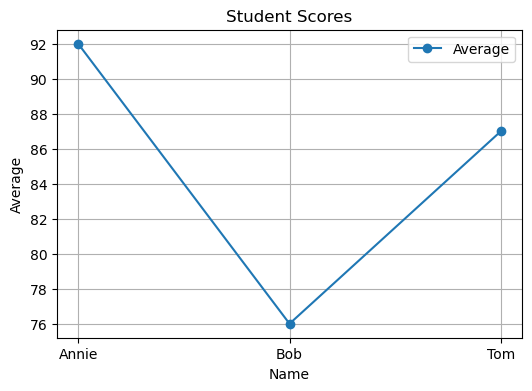

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(names, scores, marker='o', label='Average')

plt.title("Student Scores")
plt.xlabel("Name")
plt.ylabel("Average")
plt.legend()
plt.grid(True)
plt.show()

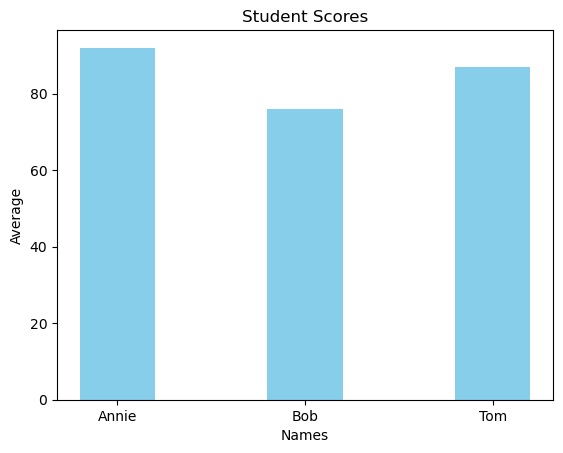

In [4]:
import matplotlib.pyplot as plt

plt.bar(names, scores, color = 'skyblue', width = 0.4)
plt.title("Student Scores")
plt.xlabel("Names")
plt.ylabel("Average")
plt.show()

## Review for midterm exam 

* Weeks 1 – 7 materials

    -- Lecture videos/notes (both part I and part II)

    -- 7 Assignments and 3 homework

    -- Related sections of the textbook

* Topics will NOT be tested in the exam:

    -- Bitwise operations

    -- enumerate(), reduce()

    -- closure in nested functions

    -- matrix

    -- permutation

    -- matplotlib

* Types of questions in the exam

    -- True or False

    -- Multiple choices 

    -- Coding

    -- Bonus question

**Anytime between October 23 – 25 EST; 100 minutes**. Once you begin the exam, the clock ticks. You must submit the exam within 100 minutes. Everyone has only one attempt -- **no multiple submissions**. A timer is suggested to track time.

Closed book, closed notes, no access to any Python shell (IDLE, Jupyter Notebook, VS Code, PyCharm, others), no use of AI.

No access to the Internet other than Canvas – Quizzes website.

**Do not discuss the exam with anyone. Do not share the exam with anyone. Do not store a copy of the exam.**

There is no makeup exam. Excused absence from the exam requires consent from the instructor before October 23.

If you are entitled to have academic accommodation, please let the instructor know before October 20.
